# Youtube Trending Video Analytics

## Analyze Youtube trending videos to identify trending patterns, viewers engagement and category-wise performance using python

In [28]:
import pandas as pd   
import numpy as np   
import matplotlib.pyplot as plt   
import seaborn as sns   
from textblob import TextBlob
plt.style.use('ggplot')

In [29]:
df = pd.read_csv("youtube.csv")
df.head()

,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161470 entries, 0 to 161469
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   index                   161470 non-null  int64
 1   video_id                161470 non-null  str  
 2   trending_date           161470 non-null  str  
 3   title                   161470 non-null  str  
 4   channel_title           161470 non-null  str  
 5   category_id             161470 non-null  int64
 6   publish_date            161470 non-null  str  
 7   time_frame              161470 non-null  str  
 8   published_day_of_week   161470 non-null  str  
 9   publish_country         161470 non-null  str  
 10  tags                    161470 non-null  str  
 11  views                   161470 non-null  int64
 12  likes                   161470 non-null  int64
 13  dislikes                161470 non-null  int64
 14  comment_count           161470 non-null  int64
 15  comments_di

In [31]:
print("Rows : ",df.shape[0])
print("Columns : ",df.shape[1])

Rows :  161470
Columns :  18


In [32]:
df.isnull().sum()

index                     0
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_date              0
time_frame                0
published_day_of_week     0
publish_country           0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.drop_duplicates(inplace=True)

In [35]:
df['trending_date'].head(10)

0    17.14.11
1    17.14.11
2    17.14.11
3    17.14.11
4    17.14.11
5    17.14.11
6    17.14.11
7    17.14.11
8    17.14.11
9    17.14.11
Name: trending_date, dtype: str

In [36]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['trending_date'] = pd.to_datetime(df['trending_date'],format='%d/%m/%Y',errors='coerce')

C:\Users\Y N CHARAN REDDY\AppData\Local\Temp\ipykernel_12820\1526918465.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['publish_date'] = pd.to_datetime(df['publish_date'])


In [37]:
df['Year'] = df['publish_date'].dt.year
df['Month'] = df['publish_date'].dt.month_name()
df['Day'] = df['publish_date'].dt.day_name()
df['Trending_Days'] = (df['trending_date'] - df['publish_date']).dt.days

In [38]:
def sentiment(text): 
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"
df['Sentiment'] = df['title'].apply(sentiment)

In [39]:
df.to_csv("youtube_cleaned.csv",index=False)

### Observation 
-Dataset loaded successfully.
-Duplicate records were removed.
-Date columns were converted into datetime format.
-New features such as Year,Month,Day and Trending Days were created.
-Sentiment labels were generated from video titles.

# Exploratory Data Analysis (EDA)

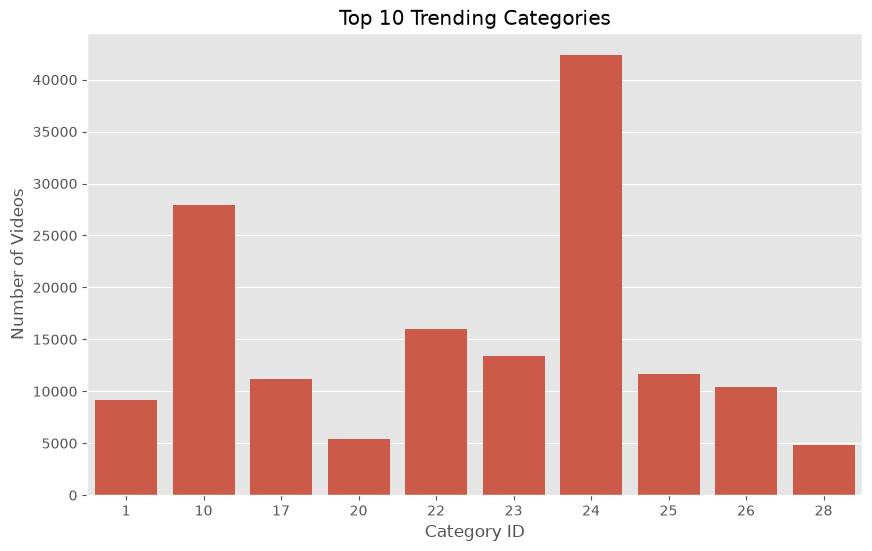

In [40]:
plt.figure(figsize=(10,6))
top_categories = df['category_id'].value_counts().head(10)
sns.barplot(x=top_categories.index,y=top_categories.values)
plt.title("Top 10 Trending Categories")
plt.xlabel("Category ID")
plt.ylabel("Number of Videos")
plt.show()

**Observation**
-A few categories dominate the trending list
-Some categories consistently appear more often than others.

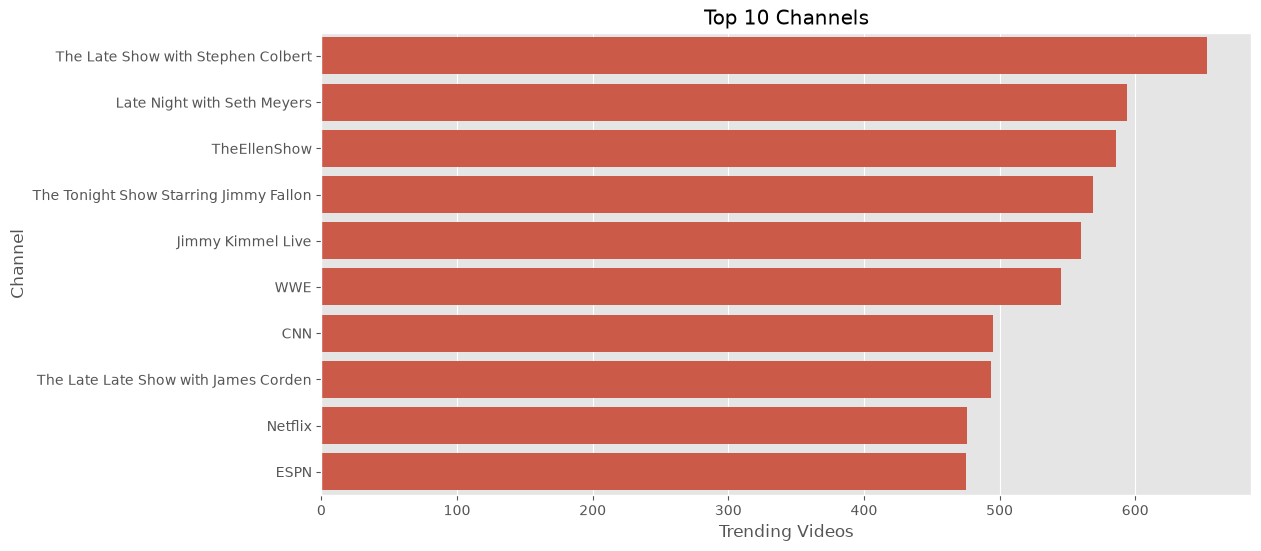

In [41]:
plt.figure(figsize=(12,6))
top_channels = df['channel_title'].value_counts().head(10)
sns.barplot(x=top_channels.values,y=top_channels.index)
plt.title("Top 10 Channels")
plt.xlabel("Trending Videos")
plt.ylabel("Channel")
plt.show()

**Observation**
A small number of channels contribute a large share of trending videos.

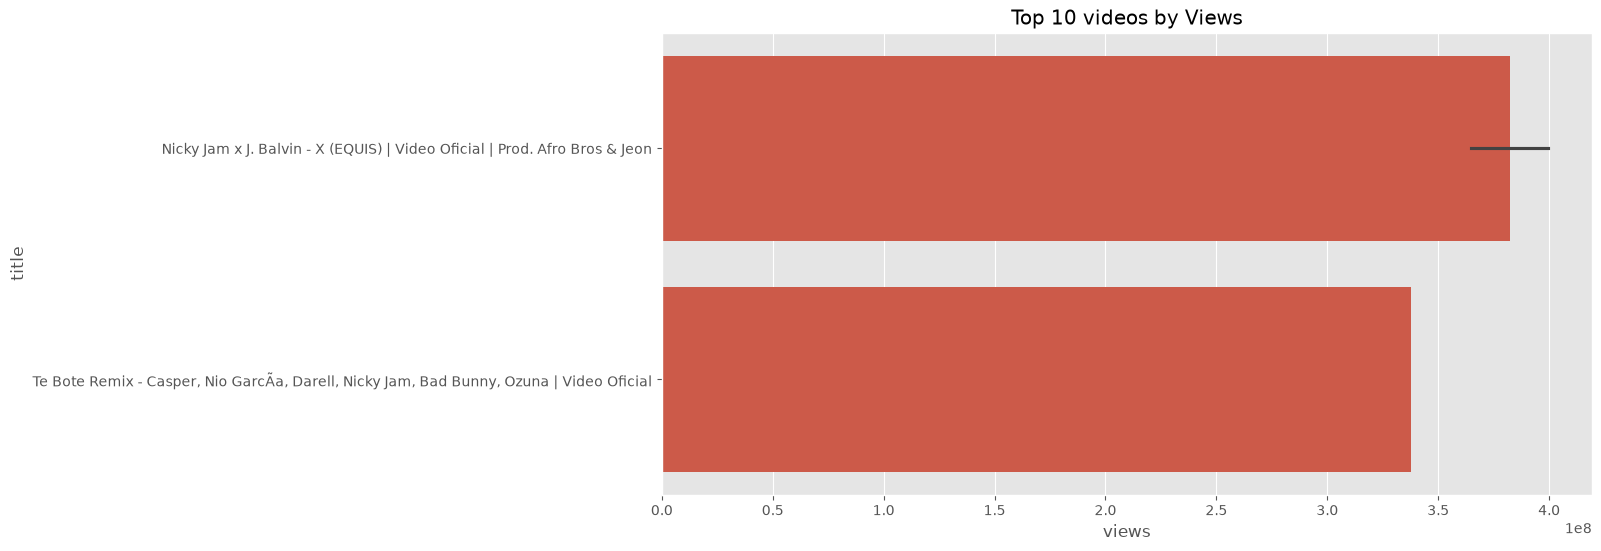

In [42]:
top_videos = df.nlargest(10,'views')
plt.figure(figsize=(12,6))
sns.barplot(data=top_videos,x='views',y='title')
plt.title("Top 10 videos by Views")
plt.show()

**Observation**
The highest-viewed videos significantly outperform the rest.

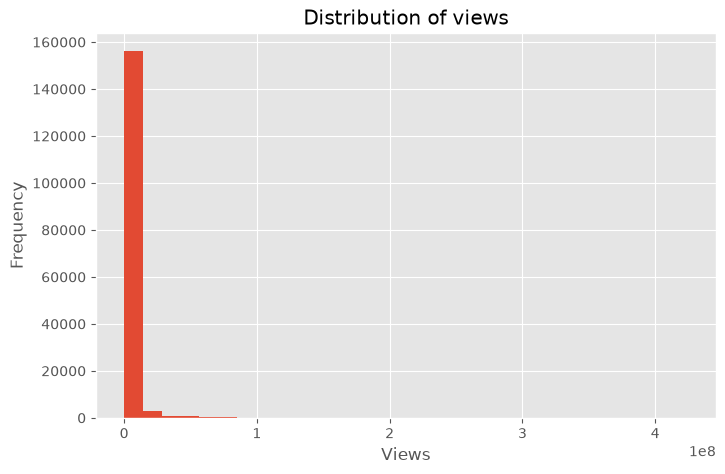

In [43]:
plt.figure(figsize=(8,5))
plt.hist(df['views'],bins=30)
plt.title("Distribution of views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

**Observation**
Most videos receive moderate views,while a few receive exceptionally high views.

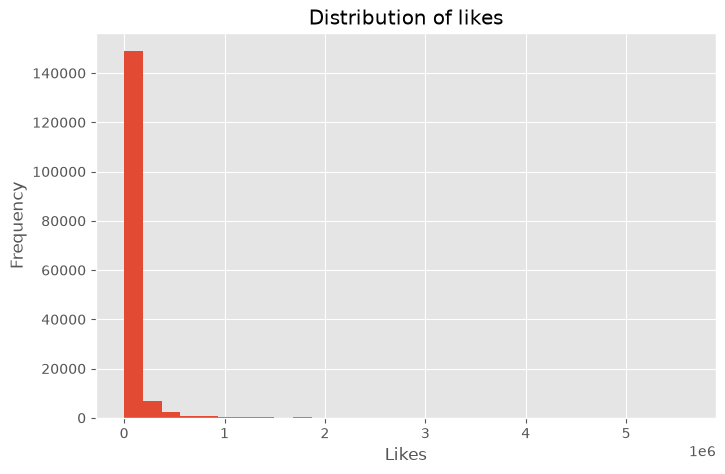

In [44]:
plt.figure(figsize=(8,5))
plt.hist(df['likes'],bins=30)
plt.title("Distribution of likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()

**Observation**
Likes are cocentrated among a limited numer of highly popular videos.

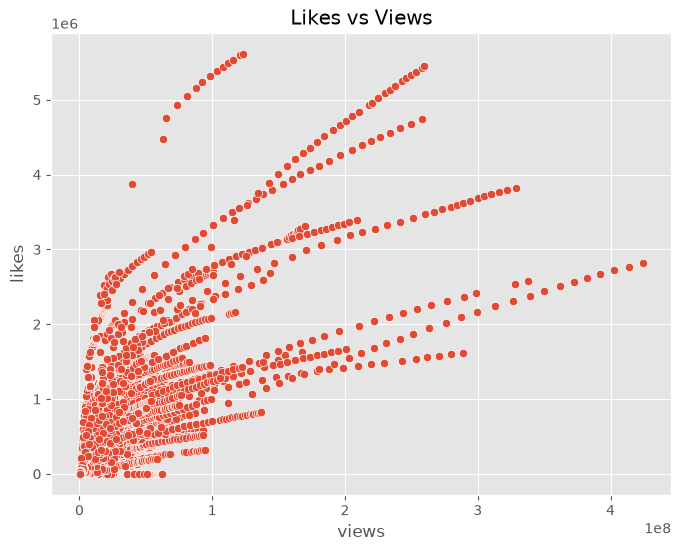

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='views',y='likes')
plt.title("Likes vs Views")
plt.show()

**Observation**
Videos with higher views generally receive more likes,showing a positive relationship.

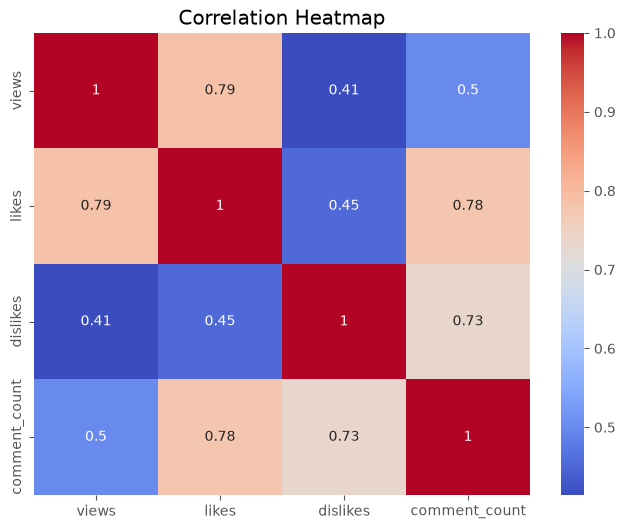

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['views','likes','dislikes','comment_count']].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Observation**
Views,likes and comments have a strong positive correlation.

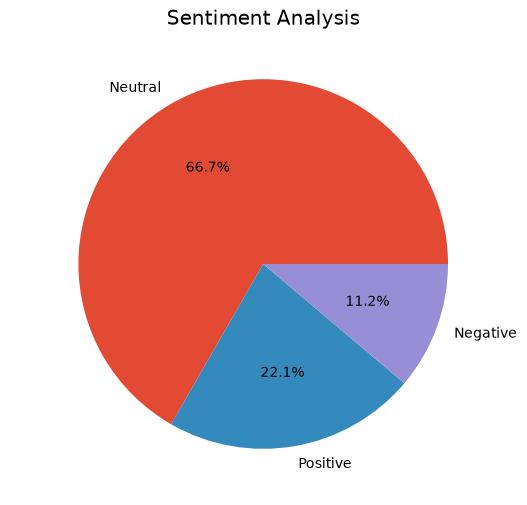

In [47]:
plt.figure(figsize=(6,6))
df['Sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel(" ")
plt.title("Sentiment Analysis")
plt.show()

**Observation**
Most trending video titles are positive or neutral

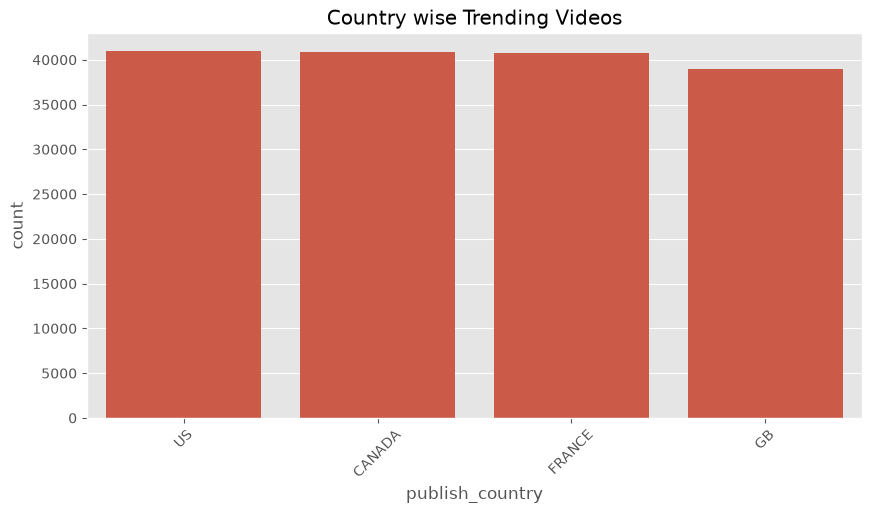

In [48]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='publish_country',order=df['publish_country'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Country wise Trending Videos")
plt.show()

**Observation**
Some countries publish considerably more trending videos than others.

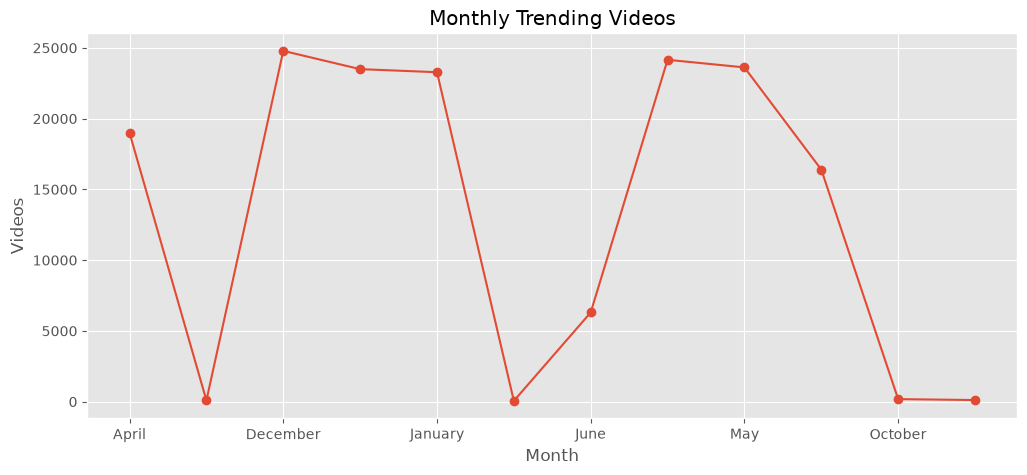

In [49]:
monthly=df.groupby('Month').size()
plt.figure(figsize=(12,5))
monthly.plot(marker='o')
plt.title("Monthly Trending Videos")
plt.ylabel("Videos")
plt.show()

**Observation**
Trending activity varies by month,indicating seasonal changes.

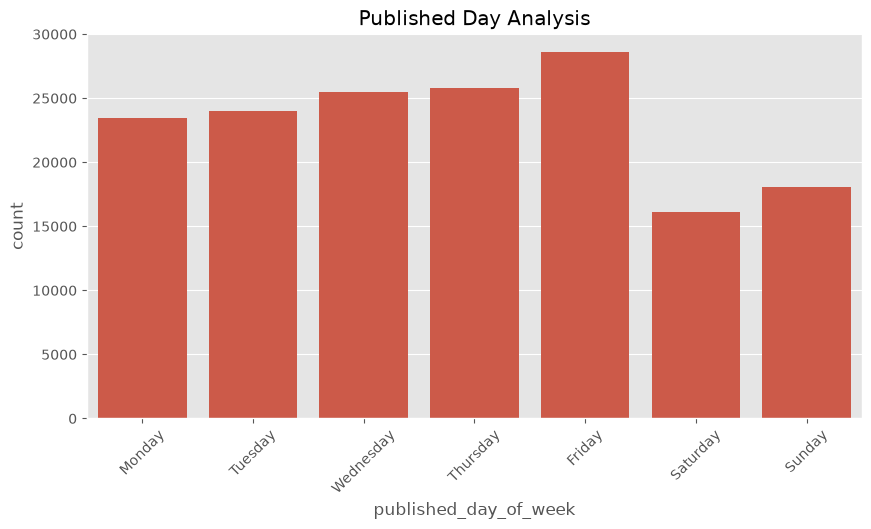

In [50]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='published_day_of_week',order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.xticks(rotation=45)
plt.title("Published Day Analysis")
plt.show()

**Observation**
Certain weekdays have noticeably more trending uploads

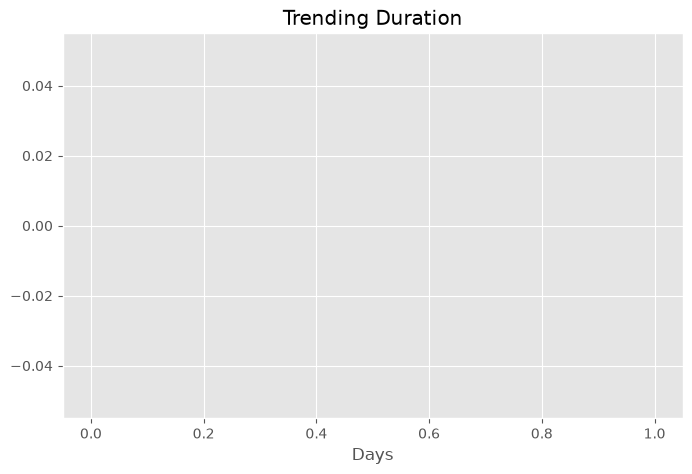

In [51]:
plt.figure(figsize=(8,5))
plt.hist(df['Trending_Days'].dropna(),bins=20)
plt.title("Trending Duration")
plt.xlabel("Days")
plt.show()

# Overall Findings
1.Entertainment related categories dominate the trending list.
2.Popular channels repeatedly appear in trending videos.
3.Higher views usually result in higher likes and comments.
4.Most video titles have positive or neutral sentiment.
5.Trending activity varies across countries and months.
6.Strong positive relationships exist among views,likes and comments.